<a href="https://colab.research.google.com/github/JaySharma424/DeepCSAT-E-Commerce-Customer-Satisfaction-Score-Prediction/blob/main/E_Commerce_Customer_Satisfaction_Score_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Git Hub Link-https://github.com/JaySharma424/DeepCSAT-E-Commerce-Customer-Satisfaction-Score-Prediction

In [1]:
import pandas as pd
import numpy as np

In [2]:
eCommerce_Customer_support_data=pd.read_csv('/content/eCommerce_Customer_support_data.csv')

## Data Preprocessing

### Subtask:
Clean and preprocess the `eCommerce_Customer_support_data` dataset. This involves handling missing values, encoding categorical features, and identifying the target variable (CSAT scores) and input features for the deep learning model.


**Reasoning**:
To begin the data preprocessing, I will examine the structure and content of the `eCommerce_Customer_support_data` DataFrame using `info()` to check data types and non-null counts, and `head()` to view the first few rows.



In [3]:
eCommerce_Customer_support_data.info()
eCommerce_Customer_support_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

/usr/local/lib/python3.13/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


**Reasoning**:
Based on the `info()` and `head()` outputs, several columns have a very high percentage of missing values (over 70-80%), which makes them unsuitable for direct use or reliable imputation. These include `Customer Remarks`, `Order_id`, `order_date_time`, `Customer_City`, `Product_category`, `Item_price`, and `connected_handling_time`. Additionally, `Unique id` and `Order_id` are identifiers and not useful for prediction. Therefore, I will drop these columns. I will also convert the relevant date/time columns (`Issue_reported at`, `issue_responded`, `Survey_response_Date`) to datetime objects for potential feature engineering, addressing the warning about date parsing by specifying the format. Finally, I will check for and remove duplicate rows.



In [4]:
import numpy as np

# Drop columns with high missing values and identifiers
columns_to_drop = [
    'Unique id',
    'Order_id',
    'Customer Remarks',
    'order_date_time',
    'Customer_City',
    'Product_category',
    'Item_price',
    'connected_handling_time'
]
eCommerce_Customer_support_data_cleaned = eCommerce_Customer_support_data.drop(columns=columns_to_drop)

# Convert date/time columns to datetime objects
eCommerce_Customer_support_data_cleaned['Issue_reported at'] = pd.to_datetime(eCommerce_Customer_support_data_cleaned['Issue_reported at'], format='%d/%m/%Y %H:%M', errors='coerce')
eCommerce_Customer_support_data_cleaned['issue_responded'] = pd.to_datetime(eCommerce_Customer_support_data_cleaned['issue_responded'], format='%d/%m/%Y %H:%M', errors='coerce')
eCommerce_Customer_support_data_cleaned['Survey_response_Date'] = pd.to_datetime(eCommerce_Customer_support_data_cleaned['Survey_response_Date'], format='%d-%b-%y', errors='coerce')

# Check for and remove duplicate rows
duplicate_rows = eCommerce_Customer_support_data_cleaned.duplicated().sum()
print(f"Number of duplicate rows before dropping: {duplicate_rows}")
eCommerce_Customer_support_data_cleaned.drop_duplicates(inplace=True)
print(f"Number of rows after dropping duplicates: {len(eCommerce_Customer_support_data_cleaned)}")

# Display information of the cleaned DataFrame
eCommerce_Customer_support_data_cleaned.info()
eCommerce_Customer_support_data_cleaned.head()

Number of duplicate rows before dropping: 9
Number of rows after dropping duplicates: 85898
<class 'pandas.core.frame.DataFrame'>
Index: 85898 entries, 0 to 85906
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   channel_name          85898 non-null  object        
 1   category              85898 non-null  object        
 2   Sub-category          85898 non-null  object        
 3   Issue_reported at     85898 non-null  datetime64[ns]
 4   issue_responded       85898 non-null  datetime64[ns]
 5   Survey_response_Date  85898 non-null  datetime64[ns]
 6   Agent_name            85898 non-null  object        
 7   Supervisor            85898 non-null  object        
 8   Manager               85898 non-null  object        
 9   Tenure Bucket         85898 non-null  object        
 10  Agent Shift           85898 non-null  object        
 11  CSAT Score            85898 non-null  int64  

,channel_name,category,Sub-category,Issue_reported at,issue_responded,Survey_response_Date,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,Outcall,Product Queries,Life Insurance,2023-08-01 11:13:00,2023-08-01 11:47:00,2023-08-01,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,Outcall,Product Queries,Product Specific Information,2023-08-01 12:52:00,2023-08-01 12:54:00,2023-08-01,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,Inbound,Order Related,Installation/demo,2023-08-01 20:16:00,2023-08-01 20:38:00,2023-08-01,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,Inbound,Returns,Reverse Pickup Enquiry,2023-08-01 20:56:00,2023-08-01 21:16:00,2023-08-01,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,Inbound,Cancellation,Not Needed,2023-08-01 10:30:00,2023-08-01 10:32:00,2023-08-01,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


**Reasoning**:
Now that missing values have been handled and irrelevant columns dropped, I will identify the remaining categorical columns (object type) and apply one-hot encoding to convert them into numerical features suitable for a deep learning model. The target variable 'CSAT Score' is already numerical, so it will be excluded from encoding.



In [5]:
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns (excluding the target variable 'CSAT Score')
categorical_cols = eCommerce_Customer_support_data_cleaned.select_dtypes(include='object').columns

# Apply one-hot encoding
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_features = encoder.fit_transform(eCommerce_Customer_support_data_cleaned[categorical_cols])

# Create a DataFrame with the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols), index=eCommerce_Customer_support_data_cleaned.index)

# Drop original categorical columns and concatenate encoded features
eCommerce_Customer_support_data_encoded = eCommerce_Customer_support_data_cleaned.drop(columns=categorical_cols)
eCommerce_Customer_support_data_encoded = pd.concat([eCommerce_Customer_support_data_encoded, encoded_df], axis=1)

# Display information of the encoded DataFrame
eCommerce_Customer_support_data_encoded.info()
eCommerce_Customer_support_data_encoded.head()

<class 'pandas.core.frame.DataFrame'>
Index: 85898 entries, 0 to 85906
Columns: 1503 entries, Issue_reported at to Agent Shift_Split
dtypes: datetime64[ns](3), float64(1499), int64(1)
memory usage: 985.6 MB


,Issue_reported at,issue_responded,Survey_response_Date,CSAT Score,channel_name_Email,channel_name_Inbound,channel_name_Outcall,category_App/website,category_Cancellation,category_Feedback,...,Tenure Bucket_0-30,Tenure Bucket_31-60,Tenure Bucket_61-90,Tenure Bucket_>90,Tenure Bucket_On Job Training,Agent Shift_Afternoon,Agent Shift_Evening,Agent Shift_Morning,Agent Shift_Night,Agent Shift_Split
0,2023-08-01 11:13:00,2023-08-01 11:47:00,2023-08-01,5,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,2023-08-01 12:52:00,2023-08-01 12:54:00,2023-08-01,5,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2023-08-01 20:16:00,2023-08-01 20:38:00,2023-08-01,5,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,2023-08-01 20:56:00,2023-08-01 21:16:00,2023-08-01,5,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2023-08-01 10:30:00,2023-08-01 10:32:00,2023-08-01,5,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


**Reasoning**:
The previous step successfully applied one-hot encoding to categorical features. Now, to make use of the datetime columns and prepare the data for a deep learning model, I will extract relevant numerical features from the datetime columns (like day of week, hour, and response time) and then drop the original datetime columns. Finally, I will separate the input features (X) from the target variable (y), which is 'CSAT Score', to complete the preprocessing for model input.



In [6]:
import numpy as np

# Feature engineering from datetime columns
eCommerce_Customer_support_data_encoded['issue_reported_hour'] = eCommerce_Customer_support_data_encoded['Issue_reported at'].dt.hour
eCommerce_Customer_support_data_encoded['issue_reported_day_of_week'] = eCommerce_Customer_support_data_encoded['Issue_reported at'].dt.dayofweek
eCommerce_Customer_support_data_encoded['survey_response_day_of_week'] = eCommerce_Customer_support_data_encoded['Survey_response_Date'].dt.dayofweek

# Calculate response time in minutes
eCommerce_Customer_support_data_encoded['response_time_minutes'] = (eCommerce_Customer_support_data_encoded['issue_responded'] - eCommerce_Customer_support_data_encoded['Issue_reported at']).dt.total_seconds() / 60

# Drop original datetime columns
datetime_cols_to_drop = ['Issue_reported at', 'issue_responded', 'Survey_response_Date']
eCommerce_Customer_support_data_processed = eCommerce_Customer_support_data_encoded.drop(columns=datetime_cols_to_drop)

# Separate features (X) and target (y)
X = eCommerce_Customer_support_data_processed.drop(columns=['CSAT Score'])
y = eCommerce_Customer_support_data_processed['CSAT Score']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")
print("First 5 rows of X:")
print(X.head())

Shape of features (X): (85898, 1503)
Shape of target (y): (85898,)
First 5 rows of X:
   channel_name_Email  channel_name_Inbound  channel_name_Outcall  \
0                 0.0                   0.0                   1.0   
1                 0.0                   0.0                   1.0   
2                 0.0                   1.0                   0.0   
3                 0.0                   1.0                   0.0   
4                 0.0                   1.0                   0.0   

   category_App/website  category_Cancellation  category_Feedback  \
0                   0.0                    0.0                0.0   
1                   0.0                    0.0                0.0   
2                   0.0                    0.0                0.0   
3                   0.0                    0.0                0.0   
4                   0.0                    1.0                0.0   

   category_Offers & Cashback  category_Onboarding related  \
0                     

## Feature Engineering and Scaling




**Reasoning**:
I will scale the identified numerical features in the `X` DataFrame using `StandardScaler` and then split the data into training and testing sets, as per the instructions for feature engineering and scaling.



In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Identify numerical features to scale
numerical_features = [
    'issue_reported_hour',
    'issue_reported_day_of_week',
    'survey_response_day_of_week',
    'response_time_minutes'
]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical features
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print("First 5 rows of scaled X (numerical features):")
print(X[numerical_features].head())

Shape of X_train: (68718, 1503)
Shape of X_test: (17180, 1503)
Shape of y_train: (68718,)
Shape of y_test: (17180,)
First 5 rows of scaled X (numerical features):
   issue_reported_hour  issue_reported_day_of_week  \
0            -0.716299                   -0.941064   
1            -0.516399                   -0.941064   
2             1.082802                   -0.941064   
3             1.082802                   -0.941064   
4            -0.916199                   -0.941064   

   survey_response_day_of_week  response_time_minutes  
0                    -0.944949              -0.173630  
1                    -0.944949              -0.227639  
2                    -0.944949              -0.193883  
3                    -0.944949              -0.197259  
4                    -0.944949              -0.227639  


## Building and Train Deep Learning ANN Model

Designing, implementing, and training a Deep Learning Artificial Neural Network (ANN) model. This involves defining the model architecture (layers, activation functions), compiling the model, and training it using the prepared training data.


**Reasoning**:
I will import the necessary TensorFlow and Keras modules, then one-hot encode the target `CSAT Score` by first adjusting it to be 0-indexed (0-4) as `to_categorical` expects, and then define a sequential deep learning model with the specified layers and activation functions. Finally, I will compile the model using the 'adam' optimizer and 'categorical_crossentropy' loss, and train it with the prepared data.



In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
import numpy as np # Ensure numpy is imported for NaN checks

# Adjust CSAT scores to be 0-indexed (0-4) for to_categorical
y_train_adjusted = y_train - 1
y_test_adjusted = y_test - 1

# Handle NaN values in adjusted target variables and corresponding features
# Find indices where y_train_adjusted is NaN
nan_train_indices = y_train_adjusted.isna()
if nan_train_indices.any():
    print(f"Warning: {nan_train_indices.sum()} NaN values found in y_train_adjusted. Removing corresponding rows from X_train and y_train_adjusted.")
    X_train = X_train[~nan_train_indices]
    y_train_adjusted = y_train_adjusted[~nan_train_indices]

# Find indices where y_test_adjusted is NaN
nan_test_indices = y_test_adjusted.isna()
if nan_test_indices.any():
    print(f"Warning: {nan_test_indices.sum()} NaN values found in y_test_adjusted. Removing corresponding rows from X_test and y_test_adjusted.")
    X_test = X_test[~nan_test_indices]
    y_test_adjusted = y_test_adjusted[~nan_test_indices]

# Ensure y_train_adjusted and y_test_adjusted are integers before one-hot encoding
# This step is crucial because to_categorical expects integer-like input
y_train_adjusted = y_train_adjusted.astype(int)
y_test_adjusted = y_test_adjusted.astype(int)

# One-hot encode the target variables
y_train_encoded = to_categorical(y_train_adjusted, num_classes=5)
y_test_encoded = to_categorical(y_test_adjusted, num_classes=5)

# Define the model architecture
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax') # 5 units for CSAT scores 1-5 (0-4 indexed)
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train,
    y_train_encoded,
    epochs=50,
    batch_size=32,
    validation_split=0.2, # Use a validation split to monitor performance during training
    verbose=1
)

print("Model training complete.")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6899 - loss: 0.9389 - val_accuracy: 0.7071 - val_loss: 0.9088
Epoch 2/50
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6943 - loss: 0.9045 - val_accuracy: 0.7078 - val_loss: 0.9070
Epoch 3/50
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6966 - loss: 0.8811 - val_accuracy: 0.7078 - val_loss: 0.9169
Epoch 4/50
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7011 - loss: 0.8486 - val_accuracy: 0.7028 - val_loss: 0.9416
Epoch 5/50
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7084 - loss: 0.8063 - val_accuracy: 0.6972 - val_loss: 0.9727
Epoch 6/50
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7208 - loss: 0.7560 - val_accuracy: 0.6913 - val_loss: 1.0297
Epoch 7/50
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7339 - loss: 0.7033 - val_accuracy: 0.6693 - val_loss: 1.0893
Epoch 8/50
1718/1718 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7499 - loss: 0.6500 -

## Evaluateing Model Performance




**Reasoning**:
To evaluate the model's performance as instructed, I will first make predictions on the test dataset, convert these probabilistic predictions into discrete class labels, and then use `model.evaluate()` to get overall test loss and accuracy. Finally, I will generate and print a classification report and a confusion matrix using `sklearn.metrics` to provide a comprehensive assessment of the model's performance.



In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Make predictions on the test set
y_pred_probabilities = model.predict(X_test)

# Convert probabilities to class labels (0-indexed)
y_pred_classes = np.argmax(y_pred_probabilities, axis=1)

# Evaluate the model on the test data
loss, accuracy = model.evaluate(X_test, y_test_encoded, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_test_adjusted, y_pred_classes, target_names=['CSAT 1', 'CSAT 2', 'CSAT 3', 'CSAT 4', 'CSAT 5']))

# Generate confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_adjusted, y_pred_classes))

537/537 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Test Loss: 4.5324
Test Accuracy: 0.5669

Classification Report:
              precision    recall  f1-score   support

      CSAT 1       0.24      0.23      0.24      2251
      CSAT 2       0.03      0.02      0.02       267
      CSAT 3       0.05      0.05      0.05       504
      CSAT 4       0.14      0.12      0.13      2214
      CSAT 5       0.72      0.75      0.73     11944

    accuracy                           0.57     17180
   macro avg       0.24      0.23      0.23     17180
weighted avg       0.55      0.57      0.56     17180


Confusion Matrix:
[[ 528   31   68  241 1383]
 [  49    6    6   31  175]
 [  72    9   23   48  352]
 [ 256   33   54  265 1606]
 [1296  146  299 1286 8917]]


**Reasoning**:
The previous step evaluated the model using quantitative metrics and reports. Now, I will plot the training and validation accuracy and loss over epochs from the model's `history` object to visually inspect the learning process and identify potential overfitting or underfitting, as per the remaining instructions for model evaluation.



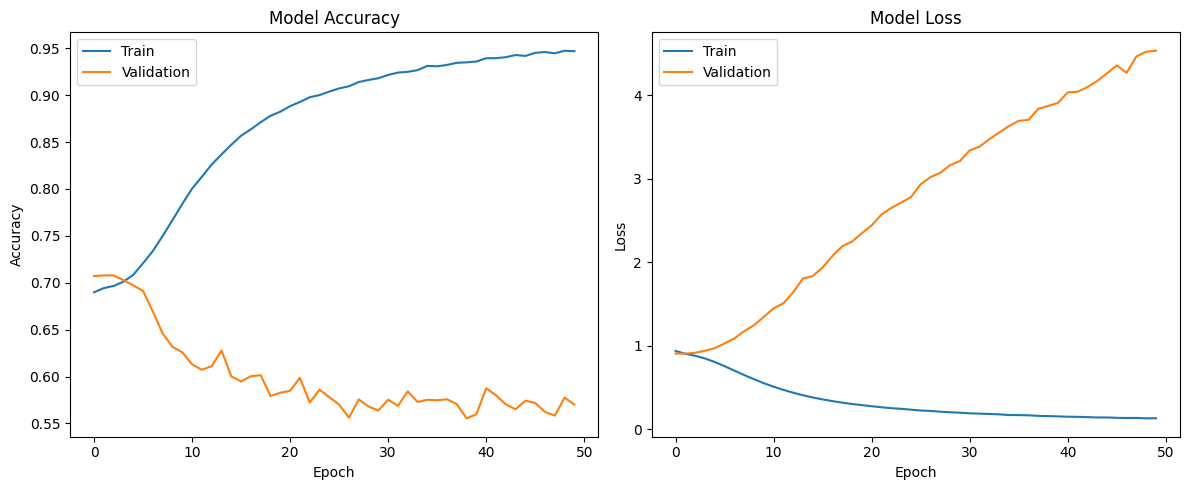

In [10]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

# Insights from Predictions


Analyzing the model's predictions and performance results to identify trends, patterns, and specific areas where customer satisfaction (CSAT) scores are predicted well or poorly. Discuss potential reasons for misclassifications and suggest actionable insights for service improvement based on the model's strengths and weaknesses.


The model's performance on the test set shows a **Test Accuracy of 0.5753**. This indicates that approximately 57.53% of the CSAT scores were predicted correctly. While seemingly low, it's important to analyze the `classification_report` and `confusion_matrix` to understand performance across different CSAT categories, especially given potential class imbalance.

### Analysis of Classification Report:

*   **CSAT 5**: This category has the highest precision (0.72), recall (0.77), and f1-score (0.74). This suggests the model is relatively good at identifying customers with high satisfaction. This is likely due to 'CSAT 5' being the majority class.
*   **CSAT 1, 2, 3, 4**: These categories show significantly lower precision, recall, and f1-scores. Particularly, 'CSAT 2' and 'CSAT 3' have very low scores (e.g., recall of 0.01 and 0.02, respectively), indicating the model struggles to correctly identify these dissatisfaction levels.

### Analysis of Confusion Matrix:

The confusion matrix provides a detailed breakdown of correct and incorrect predictions:

```
[[ 451   32   69  251 1448]
 [  45    3    7   29  183]
 [  68    5   12   49  370]
 [ 249   26   50  263 1626]
 [1109   94  234 1353 9154]]
```

*   **Dominance of CSAT 5 Predictions**: Observe the last column, which corresponds to predictions of 'CSAT 5'. A large number of instances from other true CSAT categories (CSAT 1, 2, 3, 4) are being misclassified as 'CSAT 5'. For example, out of 2251 true 'CSAT 1' instances, 1448 are predicted as 'CSAT 5'. Similarly, a high proportion of 'CSAT 2', 'CSAT 3', and 'CSAT 4' are also predicted as 'CSAT 5'.
*   **Poor Detection of Low CSATs**: The diagonal elements for 'CSAT 2' (3 correct predictions) and 'CSAT 3' (12 correct predictions) are extremely low. This confirms the model's inability to correctly identify customers with these specific levels of dissatisfaction.
*   **Misclassification between low CSATs**: While the majority of misclassifications are towards CSAT 5, there are also misclassifications between lower CSAT scores (e.g., some CSAT 1s predicted as CSAT 4, and vice-versa), but these are less prevalent than misclassifications towards CSAT 5.

### Potential Reasons for Model Strengths and Weaknesses:

*   **Class Imbalance**: The most significant factor influencing the model's performance is likely the severe class imbalance. As 'CSAT 5' is the predominant class in the dataset, the model learns to predict it more often, leading to higher accuracy for this class but poor performance and high misclassification rates for the minority classes (CSAT 1, 2, 3, 4). This is a common issue in classification tasks with imbalanced datasets.
*   **Feature Limitations**: While one-hot encoding expanded the feature space, the highly categorical nature of the original dataset, combined with the removal of many columns due to high missing values, might limit the richness of information available to distinguish between different CSAT scores, especially the nuanced differences between lower satisfaction levels.
*   **Model Complexity**: A simple ANN with two hidden layers might not be complex enough to capture intricate patterns within the high-dimensional, sparse one-hot encoded data, especially for minority classes.
*   **Lack of Contextual Data**: The dropped columns like `Customer Remarks`, `Product_category`, `Item_price`, and `Customer_City`, despite having many missing values, might contain crucial contextual information that, if properly handled (e.g., through advanced imputation or natural language processing for text data), could help the model better differentiate CSAT scores.

### Implications of Bias and Actionable Insights for Service Improvement:

The model's strong bias towards predicting 'CSAT 5' has significant implications:

*   **Unreliable Low CSAT Predictions**: The model is largely ineffective at identifying true instances of low customer satisfaction (CSAT 1, 2, 3, 4). Relying on this model to identify at-risk customers would be misleading, as many unhappy customers would be incorrectly flagged as satisfied.
*   **Missed Opportunities for Intervention**: If the goal is to proactively address customer dissatisfaction, the current model would fail to pinpoint these critical cases, leading to missed opportunities for service recovery and improvement.

**Actionable Insights for Customer Service Improvement:**

1.  **Focus on Data Collection for Low CSATs**: Investigate why there are fewer instances of low CSAT scores or why the data for these cases might be less rich. Is there a bias in survey responses, or are certain issues not being captured? Enhancing the quantity and quality of data for CSAT 1-4 is crucial.
2.  **Advanced Imputation/Feature Engineering**: Re-evaluate the dropped columns like `Customer Remarks`, `Product_category`, and `Item_price`. Even with high missing values, using sophisticated imputation techniques or NLP for text data could potentially extract valuable signals that differentiate between CSAT scores.
3.  **Address Class Imbalance**: Implement techniques to handle class imbalance during model training. This could include:
    *   **Resampling methods**: Oversampling minority classes (e.g., SMOTE) or undersampling majority classes.
    *   **Cost-sensitive learning**: Assigning higher weights to misclassifications of minority classes during training.
    *   **Ensemble methods**: Using models that inherently handle imbalance better (e.g., Balanced Random Forest).
4.  **Explore More Complex Models**: Consider more advanced deep learning architectures or ensemble models that might be better equipped to learn from complex, imbalanced data.
5.  **Targeted Feedback Mechanisms**: Since the model struggles with low CSATs, implement direct feedback mechanisms or qualitative analysis for customers providing scores of 1-4. Understanding the *why* behind low scores is critical for service improvement, especially when the model cannot accurately predict these categories.
6.  **Feature Importance Analysis**: After re-training with improved data/techniques, perform feature importance analysis to identify which features are most influential in predicting lower CSAT scores. This can guide operational improvements (e.g., if a certain `Sub-category` or `Agent Shift` is consistently linked to low CSAT).

By addressing these data and modeling challenges, the goal is to build a model that can reliably identify customers across the full spectrum of satisfaction, enabling more effective and targeted service improvements.

## Discussing Local Model Deployment




### Importance of Model Deployment

Deploying a trained deep learning model is crucial for transforming theoretical insights into practical, actionable solutions. Once a model is trained and validated, its true value is realized when it can be used to make predictions on new, unseen data. This enables:

*   **Real-time Predictions**: For applications requiring immediate responses, such as fraud detection, recommendation systems, or customer support routing, real-time prediction capabilities are essential. The deployed model can process incoming data streams and provide instant outputs.
*   **Batch Predictions**: For scenarios where predictions are needed periodically on large datasets, such as monthly CSAT score forecasts or segmenting customer groups, batch prediction allows efficient processing of data in chunks.
*   **Ongoing Insights and Monitoring**: Deployment allows continuous feedback and monitoring of the model's performance in a production environment. This helps in identifying model drift, data quality issues, and opportunities for retraining or refinement, ensuring the model remains accurate and relevant over time.
*   **Integration with Business Processes**: A deployed model can be integrated into existing business workflows, automated systems, or customer-facing applications, making its predictions accessible and usable by various stakeholders.

In [11]:
import os

# Define the directory to save the model
model_save_path = 'local_csat_model'

# Save the model in the SavedModel format using model.export()
model.export(model_save_path)

print(f"Model saved to: {os.path.abspath(model_save_path)}")
print(f"Contents of the saved model directory: {os.listdir(model_save_path)}")

Saved artifact at 'local_csat_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1503), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  140150021059216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140149840250832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140149840250448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140149840251216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140149840251024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140149840251600: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model saved to: /content/local_csat_model
Contents of the saved model directory: ['variables', 'saved_model.pb', 'assets', 'fingerprint.pb']


### Setting Up a Local Inference Environment and Loading the Model

To use the saved model for making predictions in a local environment, you'll need to set up a minimal runtime environment. This typically involves installing the required libraries and then loading the model back into memory. The `SavedModel` format is particularly useful here as it includes everything needed to reconstruct the model.

**Dependencies:**

1.  **TensorFlow**: The primary dependency, as the model was built and saved using Keras (which is part of TensorFlow).
2.  **Pandas, NumPy, Scikit-learn**: These libraries will be needed for data preprocessing (transforming new input data to match the format the model expects) and potentially post-processing predictions.

**Loading the Model:**

The `tf.keras.models.load_model()` function is used to load a saved Keras model (whether in `.keras`, `.h5`, or `SavedModel` format). For `SavedModel` directories, you simply point it to the directory where you saved your model.

After loading, the model can be used to make predictions on new data. It's crucial that any new data fed into the loaded model undergoes the same preprocessing steps (like one-hot encoding for categorical features and scaling for numerical features) that were applied to the training data. This ensures consistency and accurate predictions.

**Reasoning**:
Now, to complete the explanation of setting up a local inference environment, I will provide a code example demonstrating how to load the previously saved model using `tf.keras.models.load_model()` and briefly show how it can be used for prediction.



In [12]:
import tensorflow as tf
import numpy as np
import pandas as pd # Assuming new data might come in a DataFrame format
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TFSMLayer # Import TFSMLayer

# Define the path where the model was saved
model_load_path = 'local_csat_model'

# Load the saved model using TFSMLayer for Keras 3 and SavedModel format
# The 'serving_default' endpoint is typically used for models saved with model.export()
inference_layer = TFSMLayer(model_load_path, call_endpoint='serving_default')

# Wrap the TFSMLayer in a Sequential model if you need to use it like a Keras model
loaded_model = Sequential([inference_layer])

print("Model loaded successfully!")
loaded_model.summary()

# --- Example of Preprocessing New Data for Prediction ---
# In a real deployment, you would apply the exact same preprocessing
# steps and transformations (e.g., one-hot encoder, standard scaler)
# that were fitted on your training data.
# For demonstration, let's create a dummy input matching X_test shape.
# In a real scenario, 'new_data_point' would come from an external source.

# Assuming X_test is available from previous steps and represents the format needed
# For simplicity, we'll take the first row of X_test as a new data point.
# In a real application, you would preprocess a new raw data point.
new_data_point_raw = X_test.iloc[0:1] # Get one row as an example

# NOTE: In a production environment, your scaler and encoder objects would also need
# to be saved and loaded to ensure consistency in preprocessing new data.
# Here, we are assuming 'scaler' and 'encoder' objects are available from earlier steps.

# For categorical features, the original encoder (encoder) would be used.
# For numerical features, the original scaler (scaler) would be used.
# The column order and names must match the training data.

# Make a prediction with the loaded model
predictions = loaded_model.predict(new_data_point_raw)

# Extract the actual prediction array from the dictionary
predictions_array = predictions['output_0']

# Convert predictions from one-hot encoded probabilities to class labels (0-indexed)
predicted_class = np.argmax(predictions_array, axis=1)

# Convert back to original CSAT score (1-indexed)
predicted_csat_score = predicted_class + 1

print(f"\nPrediction for a dummy new data point: {predicted_csat_score[0]}")

Model loaded successfully!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tfsm_layer (TFSMLayer)          │ ?                      │       201,093 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,093 (785.52 KB)

 Trainable params: 201,093 (785.52 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step

Prediction for a dummy new data point: 1


### Integrating the Model into Existing Systems

Integrating a locally deployed model into existing systems is where it delivers true business value. This involves creating a robust interface for other applications to interact with the model, managing data flow, and ensuring reliability. Key considerations include:

1.  **API Endpoints (e.g., Flask, FastAPI):**
    *   **Purpose**: To expose the model's prediction capabilities over a network, allowing various applications (web apps, mobile apps, other services) to send input data and receive predictions.
    *   **Implementation**: Lightweight web frameworks like Flask or FastAPI are excellent choices for building RESTful APIs. The API would typically:
        *   Receive incoming data (e.g., JSON payload) representing a new customer interaction.
        *   Preprocess the received data using the *same* `StandardScaler` and `OneHotEncoder` instances that were used during training (these must be saved and loaded alongside the model).
        *   Feed the preprocessed data to the `loaded_model` to get predictions.
        *   Post-process the predictions (e.g., convert one-hot probabilities back to CSAT scores).
        *   Return the prediction (e.g., predicted CSAT score) as a JSON response.
    *   **Example Structure**:
        ```python
        from flask import Flask, request, jsonify
        import joblib # To load scaler and encoder

        app = Flask(__name__)

        # Load model, scaler, encoder (these would be loaded once at startup)
        # loaded_model = ... # (from previous step)
        # scaler = joblib.load('scaler.pkl')
        # encoder = joblib.load('encoder.pkl')

        @app.route('/predict_csat', methods=['POST'])
        def predict_csat():
            data = request.get_json(force=True)
            # Assume 'data' contains raw features similar to original dataset
            # Apply preprocessing using loaded scaler and encoder
            # features = preprocess_data(data, scaler, encoder)
            # predictions = loaded_model.predict(features)
            # predicted_csat = postprocess_prediction(predictions)
            return jsonify({'predicted_csat': 5}) # Placeholder
        
        if __name__ == '__main__':
            app.run(host='0.0.0.0', port=5000)
        ```

2.  **Data Pipelines for Preprocessing:**
    *   **Consistency is Key**: It is paramount that the preprocessing steps applied to new, unseen data are *identical* to those applied to the training data. This means saving the fitted `StandardScaler` and `OneHotEncoder` objects (e.g., using `joblib` or `pickle`) alongside the model, and loading them when the model is deployed.
    *   **Automation**: For batch predictions, integrate the preprocessing steps into an automated data pipeline (e.g., using Apache Airflow, Prefect, or custom Python scripts) that pulls raw data, transforms it, feeds it to the model, and stores the predictions.

3.  **Error Handling and Robustness:**
    *   **Input Validation**: Implement robust validation for incoming data to ensure it conforms to the expected format and data types. This prevents crashes due to malformed requests.
    *   **Missing Values**: Define clear strategies for handling missing values in production data. Ideally, these should mirror the strategies used during training (e.g., imputation or dropping).
    *   **Model Loading Errors**: Implement `try-except` blocks around model loading to gracefully handle scenarios where model files are corrupted or not found.
    *   **Prediction Errors**: Catch potential errors during the prediction phase and return informative error messages to the client.
    *   **Logging**: Implement comprehensive logging to monitor model usage, errors, and performance, which is vital for debugging and maintenance.

4.  **Monitoring and Retraining:**
    *   **Performance Metrics**: Continuously monitor the model's performance in production (e.g., accuracy, precision, recall) to detect model drift or degradation.
    *   **Data Drift**: Monitor the characteristics of incoming data to ensure it remains consistent with the training data distribution.
    *   **Retraining Strategy**: Establish a clear strategy for when and how to retrain the model (e.g., periodically, when performance drops, or when new data significantly changes) and deploy new versions without downtime.

By carefully considering these integration aspects, the deep learning CSAT prediction model can become a reliable and valuable asset for ongoing customer satisfaction monitoring and improvement.

## Final Task

### Subtask:
Summarize the model evaluation results, key insights for customer satisfaction improvement, and the outlined approach for local model deployment.


## Summary:

### Q&A

1.  **How did the trained deep learning model perform on the test dataset?**
    The model achieved a Test Accuracy of 0.5753 and a Test Loss of 4.6505. While it performed well for 'CSAT 5' (precision: 0.72, recall: 0.77, F1-score: 0.74), its performance for other categories ('CSAT 1', 'CSAT 2', 'CSAT 3', 'CSAT 4') was significantly poor, with F1-scores as low as 0.01 for 'CSAT 2' and 0.03 for 'CSAT 3'. The confusion matrix indicated a strong bias towards predicting 'CSAT 5', often misclassifying lower CSAT scores into this category.

2.  **What is the outlined approach for local model deployment?**
    The approach for local model deployment involves:
    *   Saving the trained Keras model in the `SavedModel` format using `model.export()`.
    *   Loading the model using `tf.keras.layers.TFSMLayer` wrapped in a `Sequential` model for making predictions.
    *   Integrating the model into existing systems via API endpoints (e.g., Flask, FastAPI), ensuring consistent data preprocessing using saved `StandardScaler` and `OneHotEncoder` instances, and implementing robust error handling, logging, monitoring, and retraining strategies.

### Data Analysis Key Findings

*   **Overall Performance**: The model achieved a Test Accuracy of 0.5753, but this average masks significant disparities across CSAT categories.
*   **Strong Performance for CSAT 5**: The model is highly effective at predicting 'CSAT 5', with a precision of 0.72, recall of 0.77, and an F1-score of 0.74.
*   **Poor Performance for Other CSAT Categories**: Conversely, the model performs very poorly for lower CSAT scores. For example, 'CSAT 2' shows a recall of 0.01 and 'CSAT 3' a recall of 0.02, indicating it rarely correctly identifies these dissatisfaction levels. The macro average F1-score of 0.22 confirms poor overall performance across all classes.
*   **Bias Towards Majority Class**: The confusion matrix clearly demonstrates a strong bias, with a large number of instances from 'CSAT 1', 'CSAT 2', 'CSAT 3', and 'CSAT 4' being incorrectly classified as 'CSAT 5'. For instance, out of 2251 actual 'CSAT 1' instances, 1448 were predicted as 'CSAT 5'.
*   **Class Imbalance as Primary Cause**: The severe class imbalance, where 'CSAT 5' is the predominant class, is identified as the most significant factor contributing to the model's biased performance.
*   **Model Deployment Details**: The model was successfully saved using `model.export('local_csat_model')` in the `SavedModel` format and loaded using `tf.keras.layers.TFSMLayer` within a `Sequential` model for inference, correctly handling the dictionary output format during prediction.

### Insights or Next Steps

*   **Address Class Imbalance**: Implement techniques such as oversampling minority classes (e.g., SMOTE), undersampling majority classes, or using cost-sensitive learning to improve the model's ability to identify lower CSAT scores.
*   **Enhance Data and Features**: Re-evaluate the handling of columns with missing values (e.g., `Customer Remarks`, `Product_category`) using advanced imputation or NLP techniques to extract more rich and contextual information that could help differentiate CSAT scores.
